In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure file paths

# Human TF promoter-level chec-seq binding signal
sumprom_chec_glob = "sumproms/*.gz"

# Motif binding score directory (see analysis code for calculation)
binding_score_base_dir = "binding_score_at_motifs"
background_binding_dir = f"{binding_score_base_dir}/background_binding_arrays"

binding_score_pattern = "__*loc-prom__*family*__fl25__*.csv"
background_binding_pattern = "__*__loc-prom__signal_bg__fl25*.npy"


## Imports

In [3]:
import numpy as np
import pandas as pd
import glob
from itertools import combinations
from scipy.stats import zscore

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Helper Functions

In [4]:
# Keep reproducible replicates within each sample group
def filter_reproducible(sumprom_all: pd.DataFrame, cutoff: float) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]

    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)

    return df[keep]


# Load the representative motif-binding table for one sample
def load_sample(sample_name: str, pattern: str):
    df_files = glob.glob(
        f"{binding_score_base_dir}/{sample_name}/{sample_name}{pattern}"
    )
    if len(df_files) != 1:
        return None

    bg_files = glob.glob(
        f"{background_binding_dir}/{sample_name}{background_binding_pattern}"
    )
    if len(bg_files) != 1:
        return None

    return pd.read_csv(df_files[0])


# Normalize stored sample objects to dataframes
def _as_df(obj):
    if obj is None:
        return None
    if isinstance(obj, tuple):
        obj = obj[-1]
    return obj if isinstance(obj, pd.DataFrame) else None


# Extract motif-level z-score and nuc-score series for one sample
def motif_series_pair_for_sample(df: pd.DataFrame):
    if df is None:
        return None, None

    req = {"motif_id", "sequence_name", "start", "z_score_norm_f7", "nuc_score_f7"}
    if not req.issubset(df.columns):
        return None, None

    tmp = df.loc[:, ["motif_id", "sequence_name", "start", "z_score_norm_f7", "nuc_score_f7"]].copy()
    tmp = tmp.dropna(subset=["motif_id", "sequence_name", "start", "z_score_norm_f7", "nuc_score_f7"])

    tmp["start"] = pd.to_numeric(tmp["start"], errors="coerce")
    tmp["z_score_norm_f7"] = pd.to_numeric(tmp["z_score_norm_f7"], errors="coerce")
    tmp["nuc_score_f7"] = pd.to_numeric(tmp["nuc_score_f7"], errors="coerce")
    tmp = tmp.dropna(subset=["start", "z_score_norm_f7", "nuc_score_f7"])

    z = tmp.set_index(["motif_id", "sequence_name", "start"])["z_score_norm_f7"]
    n = tmp.set_index(["motif_id", "sequence_name", "start"])["nuc_score_f7"]

    z = z.groupby(level=[0, 1, 2]).max()
    n = n.groupby(level=[0, 1, 2]).max()
    return z, n


# Build aligned motif matrices for all samples in one family
def build_family_motif_matrices(df_dict_representative, fam_samples):
    z_map, n_map = {}, {}
    for s in fam_samples:
        df = _as_df(df_dict_representative.get(s))
        z_ser, n_ser = motif_series_pair_for_sample(df)
        if z_ser is not None and n_ser is not None and z_ser.size > 0 and n_ser.size > 0:
            z_map[s] = z_ser
            n_map[s] = n_ser

    if len(z_map) == 0:
        return pd.DataFrame(), pd.DataFrame()

    df_z = pd.concat(z_map, axis=1, join="inner")
    df_nuc = pd.concat(n_map, axis=1, join="inner")

    df_z.columns = list(z_map.keys())
    df_nuc.columns = list(n_map.keys())

    common_idx = df_z.index.intersection(df_nuc.index)
    df_z = df_z.loc[common_idx]
    df_nuc = df_nuc.loc[common_idx]
    return df_z, df_nuc


# Read minimum-correlation values from the stored tuple format
def _mincorr_val(v):
    return float(v["min_corr"]) if isinstance(v, dict) else float(v[0])


# Order motifs so shared high-signal sites appear first
def ordered_features(df_fam, fam_samples_ordered, z_cutoff):
    idx = df_fam.index

    shared_mask = (df_fam[fam_samples_ordered] > z_cutoff).all(axis=1)
    shared_idx = idx[shared_mask]
    if len(shared_idx) > 0:
        shared_sorted = df_fam.loc[shared_idx, fam_samples_ordered].median(axis=1).sort_values(ascending=False).index
    else:
        shared_sorted = []

    remaining = idx.difference(shared_sorted)
    out = list(shared_sorted)

    for s in fam_samples_ordered:
        sub = remaining[df_fam.loc[remaining, s] > z_cutoff]
        if len(sub) > 0:
            sub_sorted = df_fam.loc[sub, s].sort_values(ascending=False).index
            out.extend(sub_sorted.tolist())
            remaining = remaining.difference(sub_sorted)

    out.extend(remaining.tolist())
    return out

## Data Loading

In [5]:
# Load promoter signal matrices from all sequencing batches
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

# Keep only reproducible replicates
corr_cutoff = 0.895
sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)

# Collapse replicates to one mean profile per TF
cols = pd.Index(sumprom_filtered.columns)
prefix = cols.to_series().str.rsplit("_", n=2).str[0]
sumprom_all = sumprom_filtered.T.groupby(prefix).mean().T

## Family Definitions

In [6]:
# Define the TF families shown in the final plot
FOXK1_WT = ["FOXP3", "FOXA2", "FOXF1", "FOXL1", "FOXL2", "FOXJ2", "FOXO3", "FOXP1", "FOXP2"]
GABPA_WT = ["ELF1", "ELF2", "ERF1", "ELK1", "ELK4", "ERG", "FLI1"]
SOX10_WT = ["SOX15", "SOX17", "SOX7", "SOX11", "SOX4", "SOX6", "SOX30", "SOX9", "SOX13", "SOX5"]
HXD10_WT = ["CDX2", "HOXA11", "HOXC10", "HOXD9", "HOXA10", "HOXC9", "HOXA9", "HOXB9", "CDX4", "HOXC13"]
GATA1_WT = ["GATA3", "GATA6", "GATA4", "GATA2", "GATA5"]
BATF3_WT = ["ATF4", "FOS", "CREB5", "ATF1", "CREB1", "ATF2"]
HEY1_WT = ["MNT", "MLXIPL", "MLX", "MXD4"]
NFAC4_WT = ["NFATC4", "NFATC3"]
TF2LY_WT = ["TGIF2LX", "TGIF2LY", "TGIF1", "TGIF2"]
PO3F2_WT = ["POU2F3", "POU3F4", "POU3F1"]

dbd_fam_dict = {
    "FOXK1": FOXK1_WT,
    "GABPA": GABPA_WT,
    "SOX10": SOX10_WT,
    "HXD10": HXD10_WT,
    "GATA1": GATA1_WT,
    "BATF3": BATF3_WT,
    "HEY1": HEY1_WT,
    "NFAC4": NFAC4_WT,
    "TF2LY": TF2LY_WT,
    "PO3F2": PO3F2_WT,
}

family_name = {
    "BATF3": "bZIP",
    "FOXK1": "Forkhead",
    "GABPA": "ETS",
    "HEY1": "bHLH",
    "HXD10": "Homeodomain\nHOX",
    "NFAC4": "Rel",
    "SOX10": "SOX",
    "TF2LY": "Homeodomain\nTALE-Type",
    "PO3F2": "Homeodomain\nPOU",
    "GATA1": "GATA",
}

exists_in_yeast = {
    "FOXK1": "yes",
    "GABPA": "no",
    "SOX10": "no",
    "HXD10": "no",
    "GATA1": "yes",
    "BATF3": "yes",
    "HEY1": "yes",
    "NFAC4": "no",
    "TF2LY": "no",
    "PO3F2": "no",
}

# Keep only TFs used in the final figure
cols_to_keep = set(sum(dbd_fam_dict.values(), []))
sumprom = sumprom_all.loc[:, sumprom_all.columns.isin(cols_to_keep)]
sumprom_z = sumprom.apply(zscore, axis=0)
good_samples = sumprom.columns

# Keep the original family display order used in the figure
fam_ranges = [
    ("FOXK1", 0, 6),
    ("BATF3", 7, 9),
    ("GATA1", 10, 13),
    ("HEY1", 14, 15),
    ("GABPA", 16, 22),
    ("NFAC4", 23, 24),
    ("TF2LY", 25, 27),
    ("PO3F2", 28, 29),
    ("HXD10", 30, 37),
    ("SOX10", 38, 41),
]


## Derived Metrics

In [7]:
# Compute the minimum within-family promoter correlation for each TF
corr = sumprom_z.corr()
sample_to_family = {s: fam for fam, ss in dbd_fam_dict.items() for s in ss}

minimum_correlation = {
    s: (lambda others: (corr.loc[s, others].min(), corr.loc[s, others].idxmin()))(
        [x for x in dbd_fam_dict[sample_to_family[s]] if x in corr.columns and x != s]
    )
    for s in corr.columns
}

# Load motif-level binding tables for the same set of TFs
df_dict_representative = {}
for sample in good_samples:
    df_dict_representative[sample] = load_sample(sample, binding_score_pattern)


## Plotting

Forkhead | min r = [0.4197551001890091, 0.29157961454692977, 0.2869494980489225, 0.23775897813815197, 0.2117729818281588, 0.18299264696258408, 0.18299264696258408] | 16/292 (5.48%)
bZIP | min r = [0.3807843963850579, 0.29437999201369947, 0.29437999201369947] | 28/119 (23.53%)
GATA | min r = [0.6663797198205522, 0.6261061275134496, 0.47619364847230866, 0.47619364847230866] | 34/122 (27.87%)
bHLH | min r = [0.2101929755284333, 0.2101929755284333] | 2/227 (0.88%)
ETS | min r = [0.6494301847158751, 0.6304337430230124, 0.5971020156333309, 0.570260763534057, 0.47633430734669807, 0.4421435868770286, 0.4421435868770286] | 44/324 (13.58%)
Rel | min r = [0.9084329057480284, 0.9084329057480284] | 112/176 (63.64%)
Homeodomain
TALE-Type | min r = [0.7240776118199611, 0.7215426905527588, 0.7215426905527588] | 111/221 (50.23%)
Homeodomain
POU | min r = [0.9644798766439012, 0.9644798766439012] | 37/49 (75.51%)
Homeodomain
HOX | min r = [0.7706939484905112, 0.7629379464462853, 0.7558788901922859, 0.751

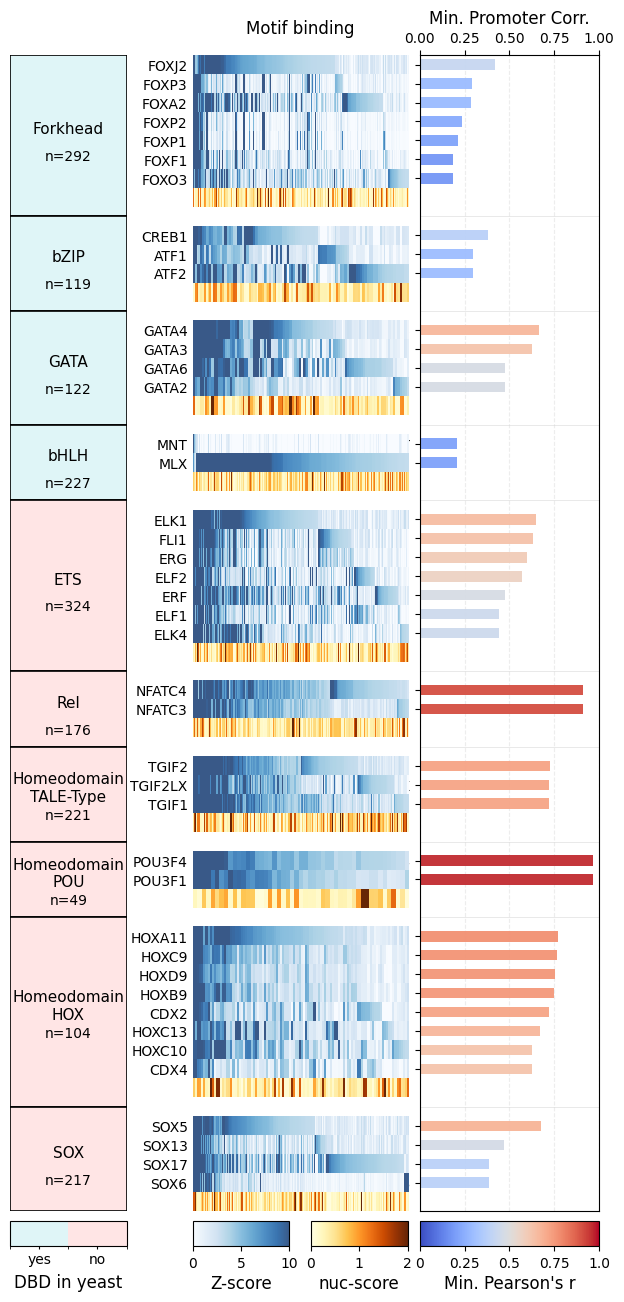

In [8]:
# Create the final combined barplot and heatmap
spacing = 2.0
gap_between = 2.0
z_cutoff = 3.0
bar_h = 1.1

hm_frac = 1.2
fam_strip_frac = 0.65
pad_fam_hm = 0.11
pad_hm_bar = 0.02

add_nuc_as_sample_row = True
nuc_row_label = ""

n = 256
c = 0.2
base_cmap = plt.get_cmap("Blues")
colors = (1.0 - c) * base_cmap(np.linspace(0.0, 1.0, n)) + c * np.ones((n, 4))
pastel_blues = mcolors.LinearSegmentedColormap.from_list("PastelGreens", colors, N=n)

vals_map = {s: _mincorr_val(v) for s, v in minimum_correlation.items()}

# Build the ordered barplot vectors, including one placeholder nuc row per family
samples_v, vals_v, ypos_v, fam_ranges_v = [], [], [], []
exists_v, name_v = {}, {}

y_current, idx0 = 0.0, 0
for fam, _, _ in fam_ranges:
    fam_samples = [s for s in dbd_fam_dict.get(fam, []) if s in vals_map]
    if not fam_samples:
        y_current += gap_between
        continue

    fam_samples = sorted(fam_samples, key=lambda s: vals_map[s], reverse=True)
    pos = y_current + spacing * np.arange(len(fam_samples), dtype=float)

    if add_nuc_as_sample_row:
        pos_all = np.append(pos, pos[-1] + spacing)
    else:
        pos_all = pos

    y_current = pos_all[-1] + spacing + gap_between

    samples_v += fam_samples
    vals_v += [vals_map[s] for s in fam_samples]
    ypos_v += pos.tolist()

    if add_nuc_as_sample_row:
        samples_v += [nuc_row_label]
        vals_v += [np.nan]
        ypos_v += [float(pos_all[-1])]

    fam_ranges_v.append((fam, idx0, idx0 + len(pos_all) - 1))
    idx0 += len(pos_all)

    exists_v[fam] = exists_in_yeast.get(fam, "no")
    name_v[fam] = family_name.get(fam, fam)

samples_v = list(samples_v)
vals_v = np.asarray(vals_v, float)
ypos_v = np.asarray(ypos_v, float)

cmap_bar = plt.cm.coolwarm
norm_bar = mpl.colors.Normalize(vmin=0.0, vmax=1.0)

fig, ax = plt.subplots(figsize=(6, 14))

# Draw the minimum-correlation bars
mask_bar = np.isfinite(vals_v)
colors_v = cmap_bar(norm_bar(vals_v[mask_bar]))
ax.barh(ypos_v[mask_bar], vals_v[mask_bar], height=bar_h, color=colors_v, alpha=0.95)

ax.set_xlim(0, 1.0)
ax.set_xticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.tick_params(axis="x", labelsize=10)
ax.set_xlabel("Min. Promoter Corr.", labelpad=6, fontsize=12)

ax.set_yticks(ypos_v)
ax.set_yticklabels([])
for tick, s in zip(ax.yaxis.get_major_ticks(), samples_v):
    if s == nuc_row_label:
        tick.tick1line.set_markersize(0)
        tick.tick2line.set_markersize(0)
ax.invert_yaxis()

ymin = float(ypos_v.min() - spacing / 2)
ymax = float(ypos_v.max() + spacing / 2)
ax.set_ylim(ymax, ymin)

ax.set_axisbelow(True)
ax.grid(axis="x", which="major", color="lightgray", linestyle="--", linewidth=0.8, alpha=0.4)
ax.margins(y=0.01)

# Separate family blocks
for (_, _, e0), (_, s1, _) in zip(fam_ranges_v[:-1], fam_ranges_v[1:]):
    ax.axhline(0.5 * (ypos_v[e0] + ypos_v[s1]), color="lightgray", lw=0.5, alpha=0.7, zorder=0)

plt.tight_layout(rect=[0.55, 0.10, 0.95, 0.98])
pos = ax.get_position()

# Add the heatmap axis and the family annotation strip
hm_w = pos.width * hm_frac
strip_w = pos.width * fam_strip_frac

hm_x0 = pos.x0 - pad_hm_bar - hm_w
ax_hm = fig.add_axes([hm_x0, pos.y0, hm_w, pos.height], sharey=ax)

ax_hm.xaxis.set_ticks_position("top")
ax_hm.xaxis.set_label_position("top")
ax_hm.set_xlabel("Motif binding", labelpad=16, fontsize=12)
ax_hm.set_xticks([])

ax_hm.set_yticks(ypos_v)
ax_hm.set_yticklabels([("ERF" if s == "ERF1" else s) for s in samples_v], fontsize=10)
ax_hm.tick_params(axis="y", length=0)
for sp in ax_hm.spines.values():
    sp.set_visible(False)

fam_x0 = hm_x0 - pad_fam_hm - strip_w
ax_fam = fig.add_axes([fam_x0, pos.y0, strip_w, pos.height], sharey=ax)
ax_fam.set_xlim(0, 1)
ax_fam.axis("off")

ax_hm.set_xlim(0, 1)
ax_hm.set_ylim(ax.get_ylim())

family_n_motifs = {}
nuc_vmin, nuc_vmax = 0, 2

# Draw one motif heatmap block per family
for fam, s0, e0 in fam_ranges_v:
    if add_nuc_as_sample_row:
        real_s0, real_e0 = s0, e0 - 1
    else:
        real_s0, real_e0 = s0, e0

    fam_samples = [s for s in samples_v[real_s0:real_e0 + 1] if (s != nuc_row_label and s in df_dict_representative)]
    if not fam_samples:
        continue

    df_z, df_nuc = build_family_motif_matrices(df_dict_representative, fam_samples)
    if df_z.empty or df_nuc.empty:
        continue

    keep = (df_z > z_cutoff).any(axis=1)
    df_z = df_z.loc[keep]
    df_nuc = df_nuc.loc[keep]

    n_total = df_z.shape[0]
    n_shared = (df_z > z_cutoff).all(axis=1).sum()
    if n_total > 0:
        print(
            f"{name_v.get(fam, fam)} | min r = {[vals_map[s] for s in fam_samples]} | "
            f"{n_shared}/{n_total} ({n_shared / n_total:.2%})"
        )

    if df_z.empty:
        continue

    family_n_motifs[fam] = df_z.shape[0]

    order = ordered_features(df_z, fam_samples, z_cutoff)
    df_z = df_z.loc[order, fam_samples]
    df_nuc = df_nuc.loc[order, fam_samples]

    # Draw the motif-binding heatmap for the real sample rows
    mat_z = df_z.T.to_numpy(dtype=float)
    y0 = ypos_v[real_s0] - spacing / 2
    y1 = ypos_v[real_e0] + spacing / 2

    ax_hm.imshow(
        mat_z,
        cmap=pastel_blues,
        vmin=0,
        vmax=10,
        aspect="auto",
        interpolation="nearest",
        extent=[0, 1, y0, y1],
        origin="lower",
    )

    # Draw the nuc-score summary as the extra bottom row
    if add_nuc_as_sample_row:
        nuc_vec = df_nuc.median(axis=1).to_numpy(dtype=float)
        mat_nuc = nuc_vec[None, :]

        y0n = ypos_v[e0] - spacing / 2
        y1n = ypos_v[e0] + spacing / 2

        ax_hm.imshow(
            mat_nuc,
            cmap=plt.cm.YlOrBr,
            vmin=nuc_vmin,
            vmax=nuc_vmax,
            aspect="auto",
            interpolation="nearest",
            extent=[0, 1, y0n, y1n],
            origin="lower",
        )

# Add the family strip on the left
yeast_no_color, yeast_yes_color = "#FFE5E5", "#DFF5F7"

ymin_lim, ymax_lim = sorted(ax.get_ylim())
for i, (fam, s0, e0) in enumerate(fam_ranges_v):
    if i == 0:
        top = ymin_lim
    else:
        ps = fam_ranges_v[i - 1][2]
        top = 0.5 * (ypos_v[ps] + ypos_v[s0])

    if i == len(fam_ranges_v) - 1:
        bot = ymax_lim
    else:
        ns = fam_ranges_v[i + 1][1]
        bot = 0.5 * (ypos_v[e0] + ypos_v[ns])

    y0, y1 = (min(top, bot), max(top, bot))
    flag = str(exists_v.get(fam, "no")).strip().lower()
    fc = yeast_yes_color if flag == "yes" else yeast_no_color

    ax_fam.add_patch(mpatches.Rectangle((0, y0), 1, y1 - y0, fc=fc, ec="black", lw=1.2))
    yc = 0.5 * (y0 + y1)
    ax_fam.text(0.5, yc - 0.7, name_v.get(fam, fam), ha="center", va="center", fontsize=11)
    ax_fam.text(0.5, yc + 2.2, f"n={family_n_motifs.get(fam, 0)}", ha="center", va="center", fontsize=10)

# Add colorbars
cb_pad, cb_h = 0.025, 0.018

sm_bar = mpl.cm.ScalarMappable(norm=norm_bar, cmap=cmap_bar)
sm_bar.set_array([])
cax_bar = fig.add_axes([pos.x0, pos.y0 - cb_pad, pos.width, cb_h])
cb_bar = fig.colorbar(sm_bar, cax=cax_bar, orientation="horizontal")
cb_bar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
cb_bar.set_ticklabels(["0", "0.25", "0.5", "0.75", "1.0"])
cb_bar.ax.tick_params(labelsize=10)
cb_bar.set_label("Min. Pearson's r", labelpad=3, fontsize=12)

pos_hm = ax_hm.get_position()
gap = 0.1 * pos_hm.width
half_w = (pos_hm.width - gap) / 2

sm_z = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=10), cmap=pastel_blues)
sm_z.set_array([])
cax_z = fig.add_axes([pos_hm.x0, pos.y0 - cb_pad, half_w, cb_h])
cb_z = fig.colorbar(sm_z, cax=cax_z, orientation="horizontal")
cb_z.ax.tick_params(labelsize=10)
cb_z.set_label("Z-score", labelpad=3, fontsize=12)

sm_n = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=nuc_vmin, vmax=nuc_vmax), cmap=plt.cm.YlOrBr)
sm_n.set_array([])
cax_n = fig.add_axes([pos_hm.x0 + half_w + gap, pos.y0 - cb_pad, half_w, cb_h])
cb_n = fig.colorbar(sm_n, cax=cax_n, orientation="horizontal")
cb_n.ax.tick_params(labelsize=10)
cb_n.set_label("nuc-score", labelpad=3, fontsize=12)

pos_fam = ax_fam.get_position()
yeast_cmap = mpl.colors.ListedColormap([yeast_yes_color, yeast_no_color])
yeast_norm = mpl.colors.BoundaryNorm([-0.5, 0.5, 1.5], yeast_cmap.N)
sm_yeast = mpl.cm.ScalarMappable(norm=yeast_norm, cmap=yeast_cmap)
sm_yeast.set_array([])
cax_yeast = fig.add_axes([pos_fam.x0, pos.y0 - cb_pad, pos_fam.width, cb_h])
cb_yeast = fig.colorbar(sm_yeast, cax=cax_yeast, orientation="horizontal")
cb_yeast.set_ticks([0, 1])
cb_yeast.set_ticklabels(["yes", "no"])
cb_yeast.ax.tick_params(labelsize=10, length=2, pad=2)
cb_yeast.set_label("DBD in yeast", labelpad=5, fontsize=12)

plt.show()